<h3>Una vez que hemos entrenado nuestros modelos de árboles y hemos elegido a nuestro ganador, vamos a compararlos y analizar cuál de ellos es mejor</h3>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, RocCurveDisplay

import os
import time
import joblib
import numpy as np
import polars as pl
import psutil

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split

# OPTUNA
import optuna

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 1. CARGA DE DATOS (100% TRAIN PARA EVALUACIÓN FINAL)
# ==========================================

path_train = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv"
path_test  = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv"

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)

TARGET_COL = "attack_cat"

# 2. Crear y_train e y_test (Normal=1, Ataque=-1)
y_train = (
    df_train.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

y_test = (
    df_test.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

x_train = df_train.drop(TARGET_COL)
x_test  = df_test.drop(TARGET_COL)

print(f"Forma de x_train: {x_train.shape} | Clases únicas en y_train: {y_train.unique().to_list()}")
print("\nDistribución de clases en Train:")
print(y_train.value_counts())
print("\nDistribución de clases en Test:")
print(y_test.value_counts())

# ==========================================
# 3. PREPARACIÓN FINAL DE ARRAYS
# ==========================================
# Asignamos el 100% de los datos directamente a las variables de entrenamiento
X_train_np = x_train.to_numpy()
y_train_np = y_train.to_numpy()

# Los datos vírgenes de Test
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

print("\n--- RESUMEN PARA LA BATALLA FINAL ---")
print(f"Entrenamiento (100% Train): {X_train_np.shape[0]} muestras")
print(f"Test (Totalmente virgen):   {X_test_np.shape[0]} muestras")

Forma de x_train: (175341, 12) | Clases únicas en y_train: [-1, 1]

Distribución de clases en Train:
shape: (2, 2)
┌───────┬────────┐
│ label ┆ count  │
│ ---   ┆ ---    │
│ i8    ┆ u32    │
╞═══════╪════════╡
│ -1    ┆ 119341 │
│ 1     ┆ 56000  │
└───────┴────────┘

Distribución de clases en Test:
shape: (2, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ -1    ┆ 45332 │
│ 1     ┆ 37000 │
└───────┴───────┘

--- RESUMEN PARA LA BATALLA FINAL ---
Entrenamiento (100% Train): 175341 muestras
Test (Totalmente virgen):   82332 muestras


Entrenando a los 4 Reyes con el 100% del dataset de Train...
  -> Entrenando Random Forest...
  -> Entrenando XGBoost...
  -> Entrenando LightGBM...
  -> Entrenando CatBoost...

¡Entrenamiento completado!

🚀 Iniciando Benchmarking de Inferencia (Bloques de 10k, 3 reps)...
  -> Midiendo hardware para Random Forest...
  -> Midiendo hardware para XGBoost...
  -> Midiendo hardware para LightGBM...


/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X d

  -> Midiendo hardware para CatBoost...

 🏆 TABLA FINAL DE RENDIMIENTO DE HARDWARE
shape: (4, 6)
┌───────────────┬─────────────┬─────────────────┬─────────────┬───────────────┬────────────────┐
│ Modelo        ┆ Latencia_ms ┆ Thruput (paq/s) ┆ Núcleos CPU ┆ Pico RAM (MB) ┆ Porcentaje CPU │
│ ---           ┆ ---         ┆ ---             ┆ ---         ┆ ---           ┆ ---            │
│ str           ┆ f64         ┆ f64             ┆ f64         ┆ f64           ┆ f64            │
╞═══════════════╪═════════════╪═════════════════╪═════════════╪═══════════════╪════════════════╡
│ Random Forest ┆ 0.00481     ┆ 207826.0        ┆ 5.9         ┆ 11.99         ┆ 6.1            │
│ XGBoost       ┆ 0.0002      ┆ 5.023662e6      ┆ 92.5        ┆ 0.0           ┆ 96.4           │
│ LightGBM      ┆ 0.00054     ┆ 1.851331e6      ┆ 88.8        ┆ 0.0           ┆ 92.5           │
│ CatBoost      ┆ 0.00048     ┆ 2.06688e6       ┆ 38.7        ┆ 1.99          ┆ 40.4           │
└───────────────┴─────────────

/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


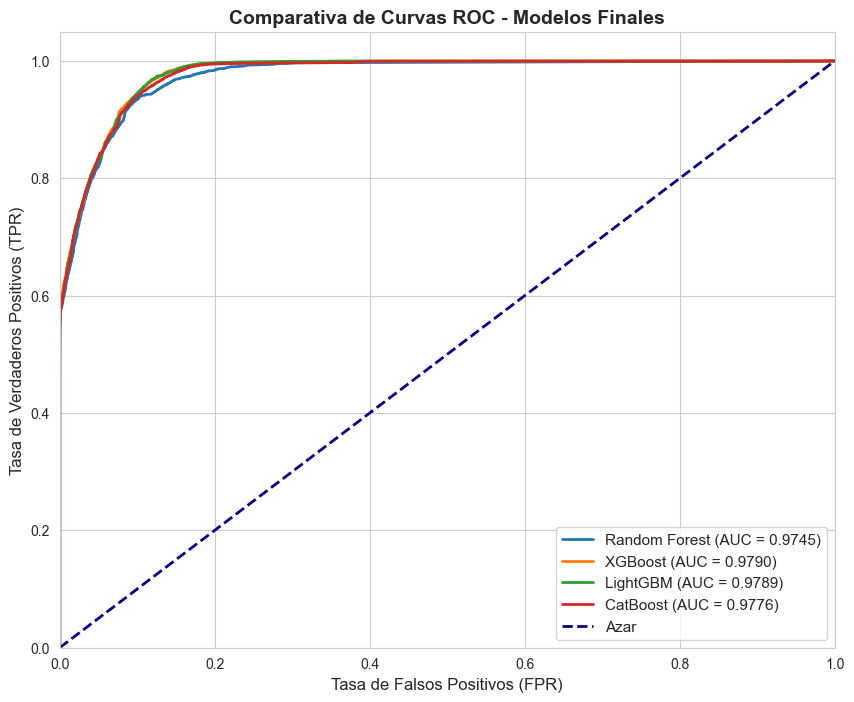

/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


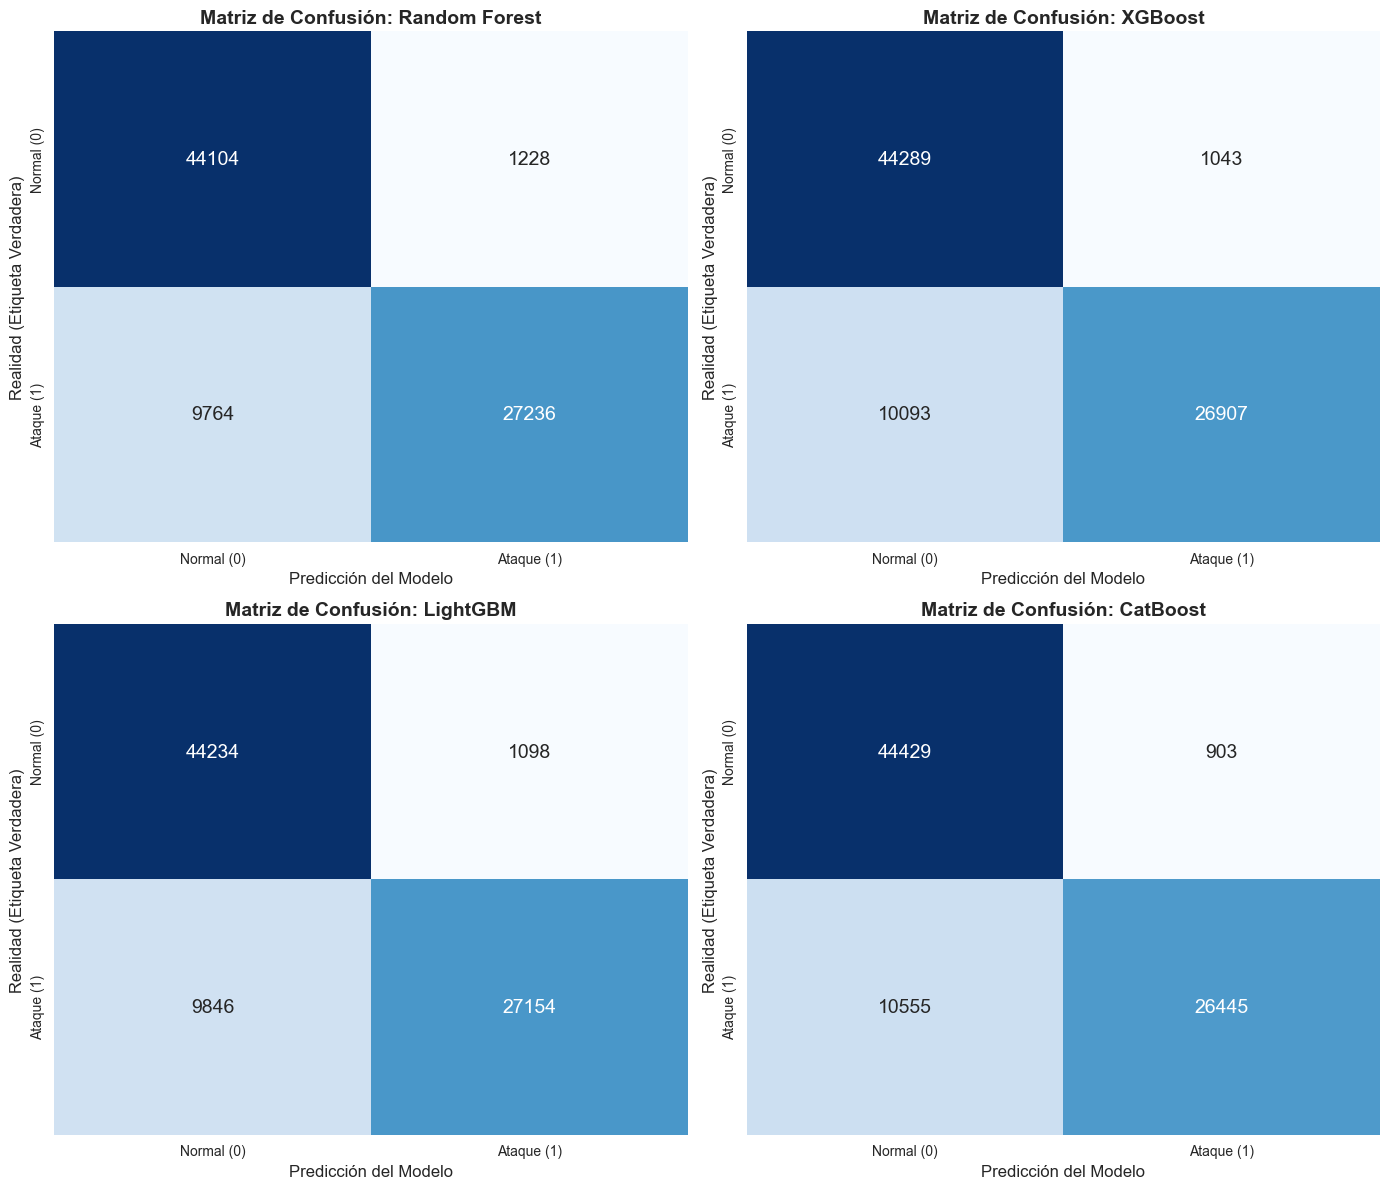

In [ ]:
# ==========================================
# 0. PREPARACIÓN DE LAS VARIABLES FALTANTES
# ==========================================
# Convertimos -1/1 a 0/1 para que XGBoost, LightGBM y CatBoost no den error
y_train_01 = ((y_train_np + 1) // 2).astype(np.int8)
y_test_np01 = ((y_test_np + 1) // 2).astype(np.int8)

# Aseguramos que X_test sea un array de NumPy puro
X_test_np_arr = np.array(X_test_np)

# ==========================================
# 1. DEFINIR LOS 4 REYES DEFINITIVOS
# ==========================================
reyes = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=25, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=350, max_depth=6, learning_rate=0.1, tree_method="hist", device="cuda", random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=150, num_leaves=127, max_depth=10, learning_rate=0.1, n_jobs=-1, random_state=42, verbosity=-1),
    "CatBoost": CatBoostClassifier(iterations=250, depth=8, learning_rate=0.1, random_seed=42, logging_level='Silent', task_type="GPU")
}

# ==========================================
# 2. ENTRENAMIENTO GLOBAL
# ==========================================
print("Entrenando a los 4 Reyes con el 100% del dataset de Train...")
modelos_entrenados = {}

for nombre, modelo in reyes.items():
    print(f"  -> Entrenando {nombre}...")
    modelo.fit(X_train_np, y_train_01)
    modelos_entrenados[nombre] = modelo

print("\n¡Entrenamiento completado!\n")

# ==========================================
# 2.1 FORZAR INFERENCIA EN CPU PARA TODOS LOS MODELOS
# ==========================================
print("Configurando inferencia en CPU para todos los modelos...")
modelos_cpu = {}

for nombre, modelo in modelos_entrenados.items():
    if nombre == "XGBoost":
        modelo.set_params(device="cpu")
    elif nombre == "CatBoost":
        modelo.set_params(task_type="CPU")

    modelos_cpu[nombre] = modelo

print("✅ Inferencia fijada en CPU.\n")

# ==========================================
# 3. BENCHMARK CIENTÍFICO (CPU Y RAM)
# ==========================================
print("🚀 Iniciando Benchmarking de Inferencia (Bloques de 10k, 3 reps)...")
resultados_benchmark = []
proceso = psutil.Process(os.getpid())
block_size = 10000
repetitions = 3

for nombre, modelo in modelos_cpu.items():
    print(f"  -> Midiendo hardware para {nombre}...")
    
    # Warm-up (fuera de la medición)
    _ = modelo.predict(X_test_np_arr[:100])
    
    tiempos_muro = []
    tiempos_cpu = []
    picos_ram = []
    
    for i in range(repetitions):
        # Fotos iniciales
        cpu_ini = proceso.cpu_times()
        ram_base = proceso.memory_info().rss / (1024 * 1024)
        pico_ram_rep = ram_base
        
        t0 = time.perf_counter()
        
        # Inferencia por bloques (Micro-batching)
        for inicio in range(0, len(X_test_np_arr), block_size):
            fin = inicio + block_size
            bloque = X_test_np_arr[inicio:fin]
            
            _ = modelo.predict(bloque)
            
            # Cazar pico de RAM
            ram_actual = proceso.memory_info().rss / (1024 * 1024)
            if ram_actual > pico_ram_rep:
                pico_ram_rep = ram_actual
                
        # Fotos finales
        t1 = time.perf_counter()
        cpu_fin = proceso.cpu_times()
        
        # Cálculos de la repetición
        tiempo_muro_rep = t1 - t0
        tiempo_cpu_rep = (cpu_fin.user - cpu_ini.user) + (cpu_fin.system - cpu_ini.system)
        
        tiempos_muro.append(tiempo_muro_rep)
        tiempos_cpu.append(tiempo_cpu_rep)
        picos_ram.append(pico_ram_rep - ram_base)
        
    # Medias de las 3 repeticiones
    media_muro = float(np.mean(tiempos_muro))
    media_cpu = float(np.mean(tiempos_cpu))
    pico_max_ram = float(np.max(picos_ram)) # Nos quedamos con el pico más bestia
    
    # Conversiones finales
    total_nucleos = psutil.cpu_count(logical=True)

    latencia_ms = (media_muro / len(X_test_np_arr)) * 1000
    paquetes_sec = len(X_test_np_arr) / media_muro
    hilos = media_cpu / media_muro if media_muro > 0 else 1
    cpu_pct = (hilos / total_nucleos) * 100
    
    resultados_benchmark.append({
        "Modelo": nombre,
        "Latencia_ms": round(latencia_ms, 5),
        "Thruput (paq/s)": round(paquetes_sec, 0),
        "Núcleos CPU": round(hilos, 1),
        "Pico RAM (MB)": round(pico_max_ram, 2),
        "Porcentaje CPU": round(cpu_pct, 1)
    })

df_benchmark = pl.DataFrame(resultados_benchmark)
print("\n" + "="*75)
print(" 🏆 TABLA FINAL DE RENDIMIENTO DE HARDWARE")
print("="*75)
print(df_benchmark)
print("="*75 + "\n")

# ==========================================
# 4. GRÁFICA 1: CURVAS ROC COMBINADAS
# ==========================================
print("Generando gráficas visuales...")
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

for nombre, modelo in modelos_cpu.items():
    # Obtener probabilidades de que sea la clase 1 (Ataque)
    y_score = modelo.predict_proba(X_test_np_arr)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_np01, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Comparativa de Curvas ROC - Modelos Finales', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.show()

# ==========================================
# 5. GRÁFICA 2: PANEL DE MATRICES DE CONFUSIÓN
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos_cpu.items()):
    y_pred = modelo.predict(X_test_np_arr)
    cm = confusion_matrix(y_test_np01, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                cbar=False, annot_kws={"size": 14})
    
    axes[i].set_title(f'Matriz de Confusión: {nombre}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicción del Modelo', fontsize=12)
    axes[i].set_ylabel('Realidad (Etiqueta Verdadera)', fontsize=12)
    axes[i].xaxis.set_ticklabels(['Normal (0)', 'Ataque (1)'])
    axes[i].yaxis.set_ticklabels(['Normal (0)', 'Ataque (1)'])

plt.tight_layout()
plt.show()

<h4>Los modelos presentan una gran capacidad de distinguir entre tráfico benigno y malicioso. Podemos ver que aunque Random Forest funciona bien, los modelos de boosting lo superan consistentemente. Los 3 modelos de boosting ofrecen un rendimiento muy similar en la capacidad de generalización.

LightGBM es el que tiene mejor AUC.

Dado que las diferencias en capacidad de detección entre los modelos son mínimas, la elección del modelo más adecuado debe basarse en métricas de eficiencia computacional como la latencia de inferencia y el consumo de recursos.</h4>